In [1]:
import pandas as pd
import json
import glob
import os
import numpy as np


def load_gnss_to_df(directory_path, hour_file_pattern="pvtSolution*.json"):
    all_files = glob.glob(os.path.join(directory_path, hour_file_pattern))
    all_files.sort()

    data_list = []

    target_keys = ['hAcc', 'vAcc', 'sAcc', 'numSV', 'hDOP', 'vDOP', 'clkB', 'clkD', 'gSpeed']

    for file_path in all_files:
        with open(file_path, 'r') as f:
            content = json.load(f)

            clean_content = {}
            min_length = None

            for key in target_keys:
                if key in content and isinstance(content[key], list):
                    clean_content[key] = content[key]

                    if min_length is None:
                        min_length = len(content[key])
                    else:
                        min_length = min(min_length, len(content[key]))

            if clean_content:

                for key in clean_content:
                    clean_content[key] = clean_content[key][:min_length]

                df_temp = pd.DataFrame(clean_content)
                data_list.append(df_temp)

    if not data_list:
        print(f"Brak plików w {directory_path} lub pliki są puste/uszkodzone.")
        return pd.DataFrame()

    return pd.concat(data_list, ignore_index=True)

In [2]:
def extract_advanced_features(df):
    data = df.copy()
    data['hAcc_log'] = np.log1p(data['hAcc'])
    features = ['hAcc_log', 'numSV', 'clkD', 'gSpeed']
    return data[features].fillna(0)

final_features = ['hAcc_log', 'numSV', 'clkD', 'gSpeed']

In [3]:
import numpy as np
base_path = 'dataset'
clean_days = ['dataset/Processed data/21', 'dataset/Processed data/22']

df_list = []
for day in clean_days:
    day_path = day
    df_day = load_gnss_to_df(day_path)
    if not df_day.empty:
        df_day = extract_advanced_features(df_day)
        df_list.append(df_day)

In [4]:
def create_sequences(data, time_steps=20):
    X = []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps)])
    return np.array(X)

In [5]:
from sklearn.preprocessing import StandardScaler
import numpy as np

full_train_df = pd.concat(df_list, ignore_index=True)
scaler = StandardScaler()
scaler.fit(full_train_df[final_features])

all_sequences = []

for df_day in df_list:
    scaled_data = scaler.transform(df_day[final_features])

    day_seq = create_sequences(scaled_data, time_steps=20)

    all_sequences.append(day_seq)

X_train = np.concatenate(all_sequences, axis=0)

print(f"Finalny kształt zbioru treningowego: {X_train.shape}")

Finalny kształt zbioru treningowego: (172493, 20, 4)


In [6]:
path_dec = 'dataset/1221'

df_test_raw = load_gnss_to_df(path_dec)

print(f"Wczytano {len(df_test_raw)} testowych.")

Wczytano 17976 testowych.


In [8]:
df_test_ext = extract_advanced_features(df_test_raw)

test_scaled = scaler.transform(df_test_ext[final_features])

X_test = create_sequences(test_scaled, time_steps=20)

print(f"Dane testowe gotowe. Kształt X_test: {X_test.shape}")
print(f"Liczba cech: {X_test.shape[2]}")

Dane testowe gotowe. Kształt X_test: (17956, 20, 4)
Liczba cech: 4


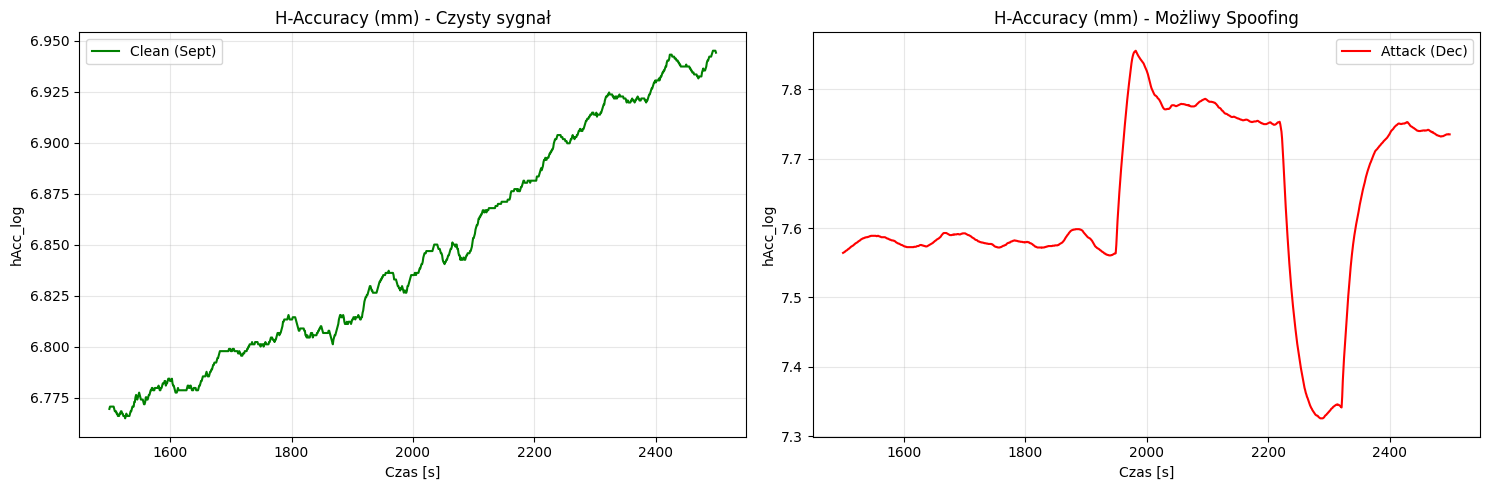

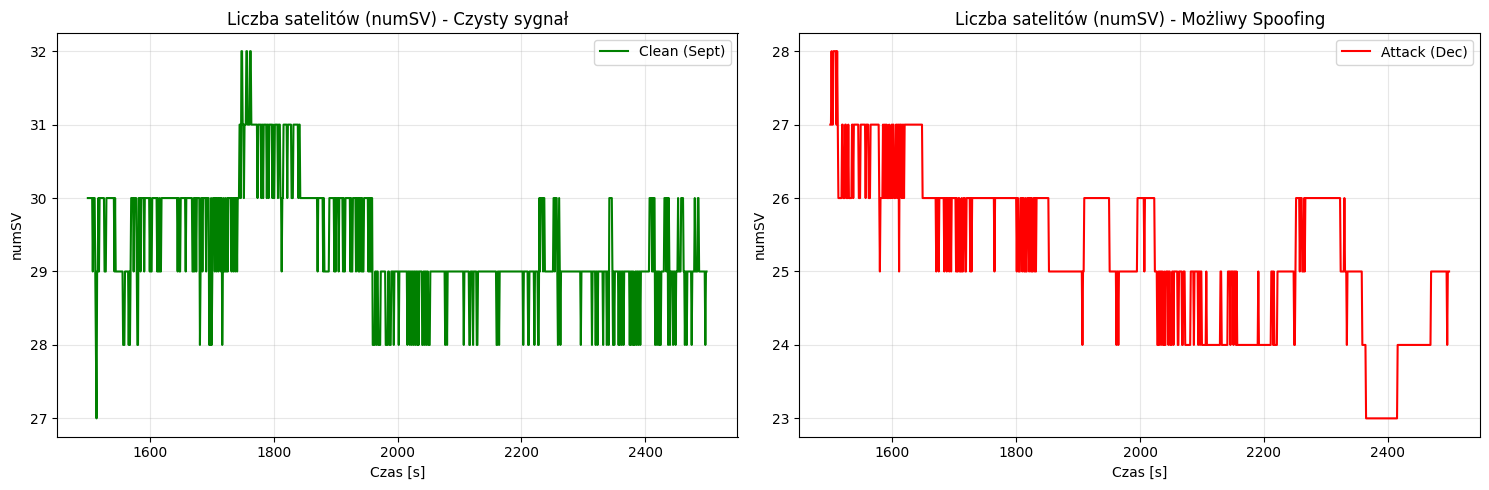

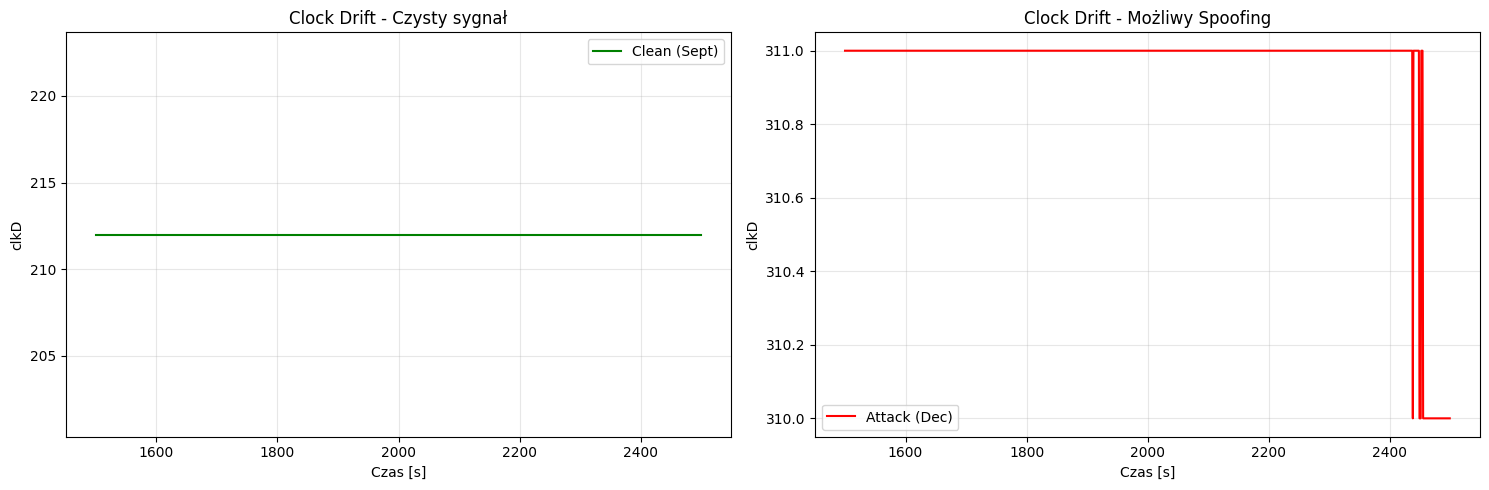

In [9]:
import matplotlib.pyplot as plt

def plot_gnss_comparison(df_train, df_test, feature='hAcc', title="Porównanie parametru"):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df_train[feature][1500:2500], color='green', label='Clean (Sept)')
    plt.title(f"{title} - Czysty sygnał")
    plt.ylabel(feature)
    plt.xlabel("Czas [s]")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(df_test[feature][1500:2500], color='red', label='Attack (Dec)')
    plt.title(f"{title} - Możliwy Spoofing")
    plt.ylabel(feature)
    plt.xlabel("Czas [s]")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_gnss_comparison(full_train_df, df_test_ext, feature='hAcc_log', title="H-Accuracy (mm)")
plot_gnss_comparison(full_train_df, df_test_ext, feature='numSV', title="Liczba satelitów (numSV)")

plot_gnss_comparison(full_train_df, df_test_ext, feature='clkD', title="Clock Drift")

In [19]:
raw_attacks = [
    ("12:32:30", "12:37:00"), ("12:38:41", "12:41:20"), ("12:44:05", "12:55:50"),
    ("12:57:00", "13:02:00"), ("13:18:30", "13:23:40"), ("13:27:50", "13:37:50"),
    ("13:37:00", "13:46:00"), ("13:47:10", "13:56:00"), ("13:56:05", "13:59:59"),
    ("14:05:00", "14:10:18"), ("14:12:00", "14:15:00"), ("14:18:00", "14:30:00"),
    ("14:35:00", "14:40:15"), ("14:45:00", "14:50:30"), ("14:52:00", "14:58:00"),
    ("15:11:00", "15:15:00"), ("15:17:00", "15:30:00"), ("15:43:00", "15:48:00"),
    ("15:55:00", "16:00:00"), ("16:10:00", "16:15:30"), ("16:20:00", "16:23:00"),
    ("16:30:00", "16:36:00"), ("16:40:00", "16:44:00")
]

In [18]:
def get_ground_truth(n_samples, start_hour=12):
    y_true = np.zeros(n_samples)
    raw_attacks = [
    ("12:32:30", "12:37:00"), ("12:38:41", "12:41:20"), ("12:44:05", "12:55:50"),
    ("12:57:00", "13:02:00"), ("13:18:30", "13:23:40"), ("13:27:50", "13:37:50"),
    ("13:37:00", "13:46:00"), ("13:47:10", "13:56:00"), ("13:56:05", "13:59:59"),
    ("14:05:00", "14:10:18"), ("14:12:00", "14:15:00"), ("14:18:00", "14:30:00"),
    ("14:35:00", "14:40:15"), ("14:45:00", "14:50:30"), ("14:52:00", "14:58:00"),
    ("15:11:00", "15:15:00"), ("15:17:00", "15:30:00"), ("15:43:00", "15:48:00"),
    ("15:55:00", "16:00:00"), ("16:10:00", "16:15:30"), ("16:20:00", "16:23:00"),
    ("16:30:00", "16:36:00"), ("16:40:00", "16:44:00")
]
    for start_s, end_s in raw_attacks:
        h1, m1, s1 = map(int, start_s.split(':'))
        h2, m2, s2 = map(int, end_s.split(':'))

        t_start = (h1 - start_hour) * 3600 + m1 * 60 + s1
        t_end = (h2 - start_hour) * 3600 + m2 * 60 + s2

        if t_start < n_samples:
            y_true[t_start:min(t_end, n_samples)] = 1
    return y_true

In [20]:
analysis_df = df_test_ext.copy()
analysis_df['Is_Attack'] = get_ground_truth(len(analysis_df))

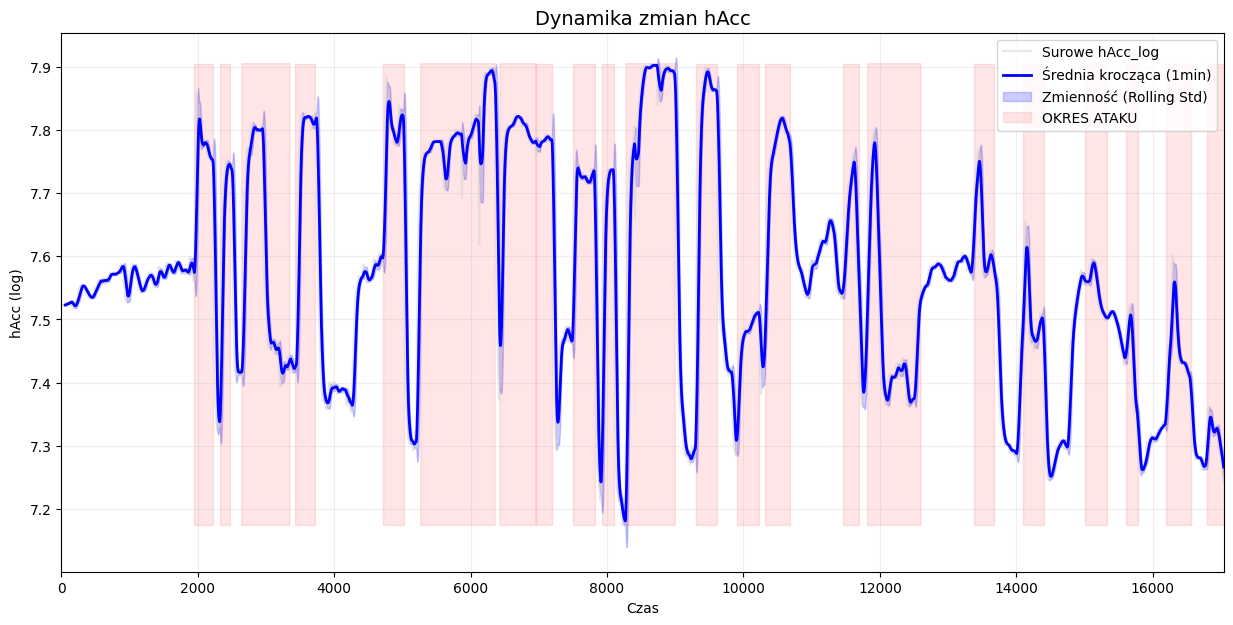

In [21]:
limit_sec = (16 - 12) * 3600 + 44 * 60 # 16:44

df_plot = analysis_df.iloc[:limit_sec].copy()

window_size = 60
df_plot['hAcc_rolling_mean'] = df_plot['hAcc_log'].rolling(window=window_size).mean()
df_plot['hAcc_rolling_std'] = df_plot['hAcc_log'].rolling(window=window_size).std()

plt.figure(figsize=(15, 7))

plt.plot(df_plot['hAcc_log'], color='lightgray', alpha=0.5, label='Surowe hAcc_log')
plt.plot(df_plot['hAcc_rolling_mean'], color='blue', lw=2, label='Średnia krocząca (1min)')

plt.fill_between(range(len(df_plot)),
                 df_plot['hAcc_rolling_mean'] - df_plot['hAcc_rolling_std'],
                 df_plot['hAcc_rolling_mean'] + df_plot['hAcc_rolling_std'],
                 color='blue', alpha=0.2, label='Zmienność (Rolling Std)')

y_min, y_max = df_plot['hAcc_log'].min(), df_plot['hAcc_log'].max()
plt.fill_between(range(len(df_plot)), y_min, y_max,
                 where=df_plot['Is_Attack']==1, color='red', alpha=0.1, label='OKRES ATAKU')

plt.title("Dynamika zmian hAcc", fontsize=14)
plt.xlabel("Czas")
plt.ylabel("hAcc (log)")
plt.xlim(0, limit_sec)
plt.grid(True, alpha=0.2)
plt.legend(loc='upper right')

plt.show()

C:\Users\kalin\AppData\Local\Temp\ipykernel_33464\296872463.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Atak"])
C:\Users\kalin\AppData\Local\Temp\ipykernel_33464\296872463.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Atak"])
C:\Users\kalin\AppData\Local\Temp\ipykernel_33464\296872463.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Normal", "Atak"])


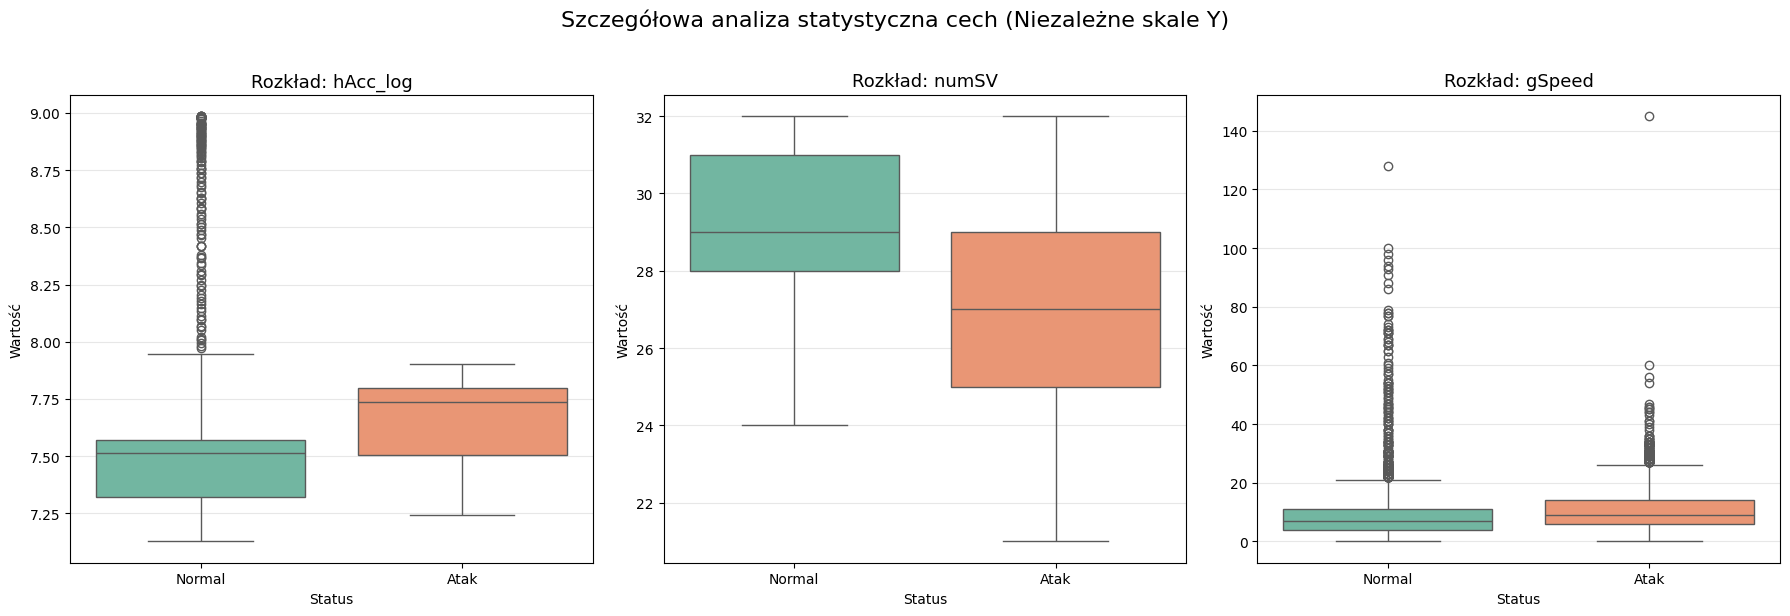

In [22]:
import seaborn as sns
df_plot = analysis_df
features = ['hAcc_log', 'numSV', 'gSpeed']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(features):
    sns.boxplot(
        data=df_plot,
        x='Is_Attack',
        y=feature,
        ax=axes[i],
        palette='Set2',
        hue='Is_Attack',
        legend=False
    )

    axes[i].set_title(f"Rozkład: {feature}", fontsize=13)
    axes[i].set_xticklabels(["Normal", "Atak"])
    axes[i].set_xlabel("Status")
    axes[i].set_ylabel("Wartość")
    axes[i].grid(True, axis='y', alpha=0.3)

plt.suptitle("Szczegółowa analiza statystyczna cech (Niezależne skale Y)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Dropout
from sklearn.preprocessing import StandardScaler

model = Sequential([
    LSTM(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2),
    RepeatVector(X_train.shape[1]),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.2),
    TimeDistributed(Dense(X_train.shape[2]))
])

model.compile(optimizer='adam', loss='mae')

c:\Users\kalin\Desktop\kościuszkon\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )
]

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 0.2676 - val_loss: 0.2017 - learning_rate: 0.0010
Epoch 2/50
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - loss: 0.2505 - val_loss: 0.1959 - learning_rate: 0.0010
Epoch 3/50
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - loss: 0.2451 - val_loss: 0.1908 - learning_rate: 0.0010
Epoch 4/50
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - loss: 0.2393 - val_loss: 0.1856 - learning_rate: 0.0010
Epoch 5/50
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - loss: 0.2343 - val_loss: 0.1798 - learning_rate: 0.0010
Epoch 6/50
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 56s 23ms/step - loss: 0.2299 - val_loss: 0.1714 - learning_rate: 0.0010
Epoch 7/50
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 106s 33ms/step - loss: 0.2261 - val_loss: 0.1734 - learning_rate: 0.0010
Epoch 8/50
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - loss: 0.2221 - val_loss: 0.1692 - learning_rate: 0.0010
Epoch 9/50
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 68s 28ms/step - loss: 0.2191 - val_loss: 0.16

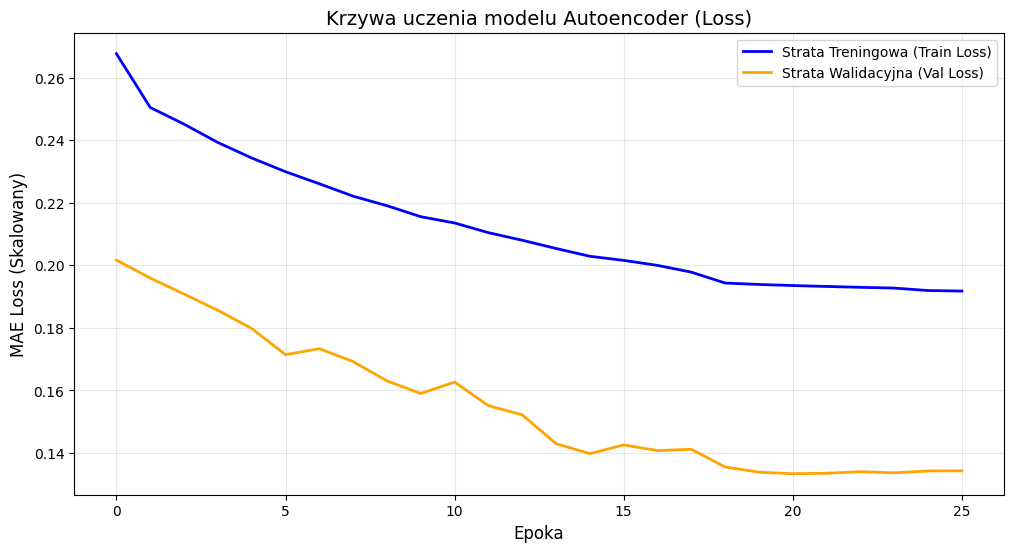

In [12]:
import matplotlib.pyplot as plt

def plot_learning_history(history):
    plt.figure(figsize=(12, 6))

    plt.plot(history.history['loss'], label='Strata Treningowa (Train Loss)', color='blue', lw=2)
    plt.plot(history.history['val_loss'], label='Strata Walidacyjna (Val Loss)', color='orange', lw=2)

    plt.title('Krzywa uczenia modelu Autoencoder (Loss)', fontsize=14)
    plt.xlabel('Epoka', fontsize=12)
    plt.ylabel('MAE Loss (Skalowany)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()


    plt.show()

plot_learning_history(history)

In [30]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.dates as mdates
from datetime import datetime, timedelta

X_train_pred = model.predict(X_train)
train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=(1, 2))

threshold = np.percentile(train_mae_loss, 99.0)
print(f"Wyznaczony próg detekcji (Threshold): {threshold:.4f}")

5391/5391 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step
Wyznaczony próg detekcji (Threshold): 0.2858


In [31]:
X_test_pred = model.predict(X_test)
scores_full = np.mean(np.abs(X_test_pred - X_test), axis=(1, 2))
limit_sec = 17100
scores_raw = scores_full[:limit_sec]

window_size = 15
scores_smoothed = pd.Series(scores_raw).rolling(window=window_size, min_periods=1).mean().values

predictions = [1 if s > threshold else 0 for s in scores_smoothed]

y_true = get_ground_truth(len(predictions))

report = classification_report(y_true, predictions, target_names=['Normal', 'SPOOFING'], output_dict=True)
acc = accuracy_score(y_true, predictions)

print(f"\n--- GLOBALNY RAPORT SKUTECZNOŚCI ---")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Precision (SPOOFING): {report['SPOOFING']['precision']*100:.2f}%")
print(f"Recall (SPOOFING): {report['SPOOFING']['recall']*100:.2f}%")
print(f"F1-Score: {report['SPOOFING']['f1-score']*100:.2f}%")

562/562 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

--- GLOBALNY RAPORT SKUTECZNOŚCI ---
Accuracy: 72.85%
Precision (SPOOFING): 70.94%
Recall (SPOOFING): 77.42%
F1-Score: 74.04%


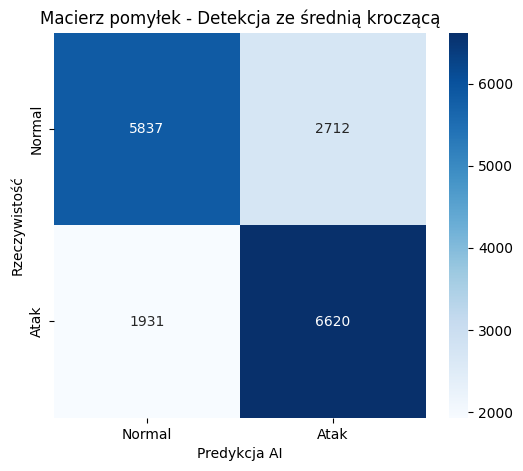

In [32]:
cm = confusion_matrix(y_true, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Atak'], yticklabels=['Normal', 'Atak'])
plt.title("Macierz pomyłek - Detekcja ze średnią kroczącą")
plt.ylabel('Rzeczywistość')
plt.xlabel('Predykcja AI')
plt.show()


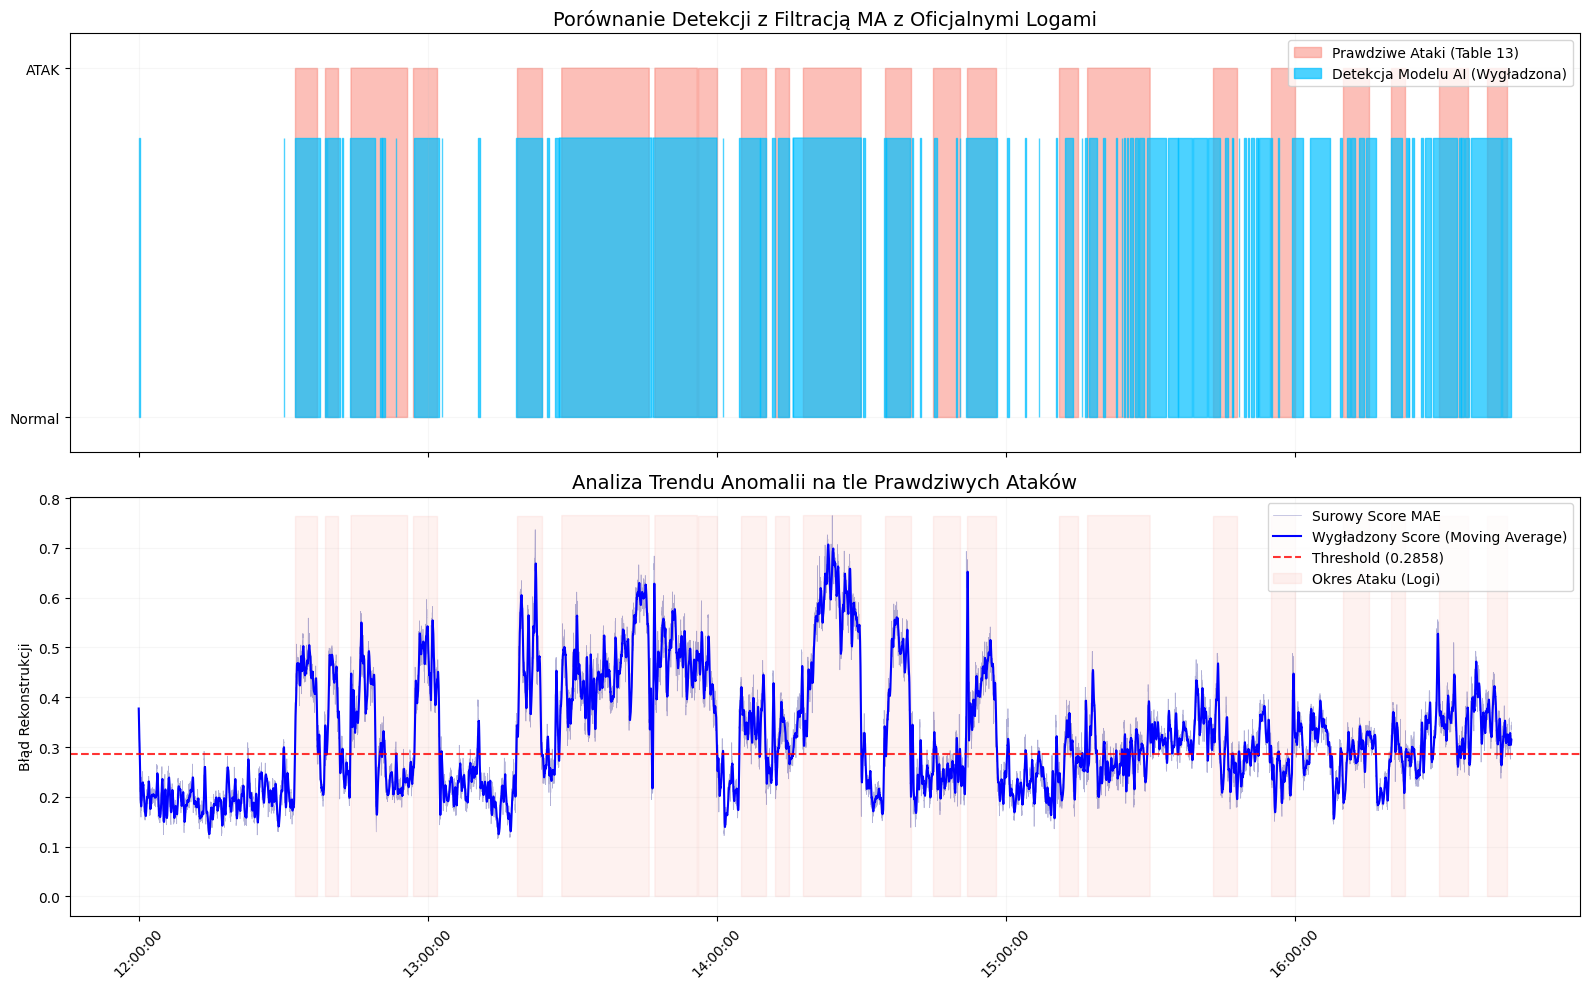

In [33]:
start_time = datetime.strptime("12:00:00", "%H:%M:%S")
time_axis = [start_time + timedelta(seconds=i) for i in range(len(scores_smoothed))]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)


ax1.fill_between(time_axis, 0, 1, where=np.array(y_true)==1,
                 color='salmon', alpha=0.5, label='Prawdziwe Ataki (Table 13)')
ax1.fill_between(time_axis, 0, 0.8, where=np.array(predictions)==1,
                 color='deepskyblue', alpha=0.7, label='Detekcja Modelu AI (Wygładzona)')
ax1.set_ylim(-0.1, 1.1)
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Normal', 'ATAK'])
ax1.set_title("Porównanie Detekcji z Filtracją MA z Oficjalnymi Logami", fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.1)

ax2.plot(time_axis, scores_raw, color='navy', lw=0.5, alpha=0.3, label='Surowy Score MAE')
ax2.plot(time_axis, scores_smoothed, color='blue', lw=1.5, label='Wygładzony Score (Moving Average)')
ax2.axhline(y=threshold, color='red', linestyle='--', alpha=0.8, label=f'Threshold ({threshold:.4f})')
ax2.fill_between(time_axis, 0, max(scores_raw), where=np.array(y_true)==1,
                 color='salmon', alpha=0.1, label='Okres Ataku (Logi)')
ax2.set_ylabel("Błąd Rekonstrukcji")
ax2.set_title("Analiza Trendu Anomalii na tle Prawdziwych Ataków", fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.1)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
delays = []
for start_s, end_s in raw_attacks:
    h1, m1, s1 = map(int, start_s.split(':'))
    t_start = (h1 - 12) * 3600 + m1 * 60 + s1

    if t_start < len(predictions):
        window = predictions[t_start : t_start + 60]
        if 1 in window:
            delay = np.where(np.array(window) == 1)[0][0]
            delays.append(delay)

if delays:
    print(f"Średni czas reakcji na atak: {np.mean(delays):.2f} sekund")

Średni czas reakcji na atak: 4.59 sekund


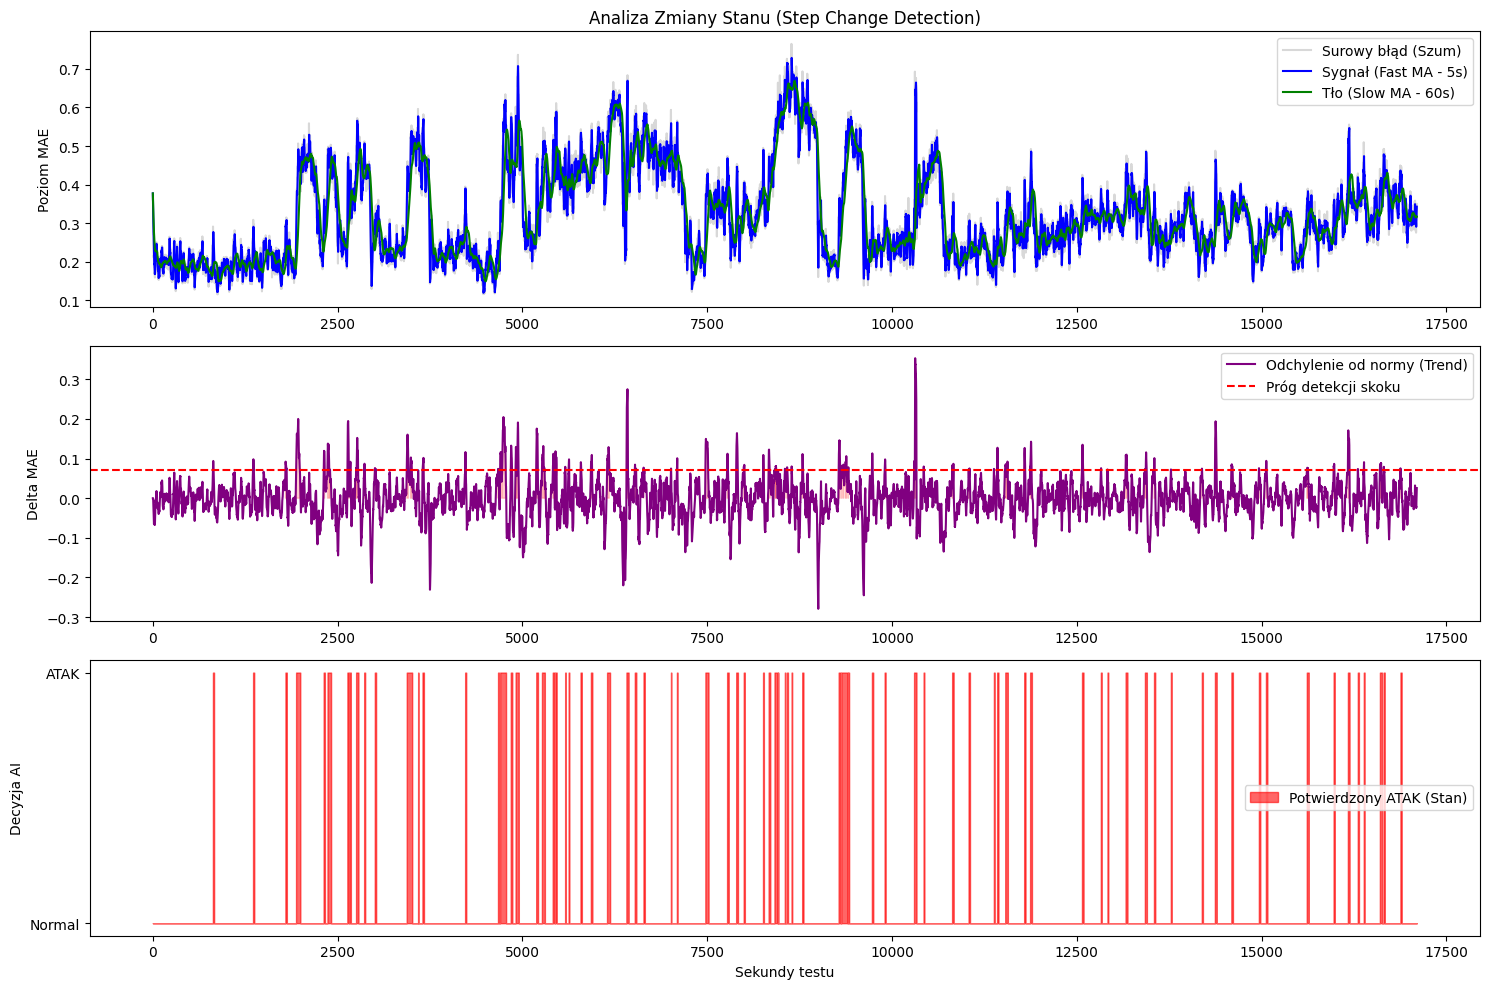

--- RAPORT DETEKCJI ZMIANY STANU ---
              precision    recall  f1-score   support

      Normal       0.52      0.93      0.67      8549
    SPOOFING       0.68      0.14      0.24      8551

    accuracy                           0.54     17100
   macro avg       0.60      0.54      0.45     17100
weighted avg       0.60      0.54      0.45     17100



In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

scores_raw = np.mean(np.abs(X_test_pred - X_test), axis=(1, 2))
scores_raw = scores_raw[:17100]

fast_ma = pd.Series(scores_raw).rolling(window=5, min_periods=1).mean()
slow_ma = pd.Series(scores_raw).rolling(window=60, min_periods=1).mean()

deviation = fast_ma - slow_ma
sensitivity_threshold = 0.07

predictions = []
is_alert = False
for val in deviation:
    if val > sensitivity_threshold:
        is_alert = True
    elif val < (sensitivity_threshold * 0.4):
        is_alert = False
    predictions.append(1 if is_alert else 0)

plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(scores_raw, color='gray', alpha=0.3, label='Surowy błąd (Szum)')
plt.plot(fast_ma, color='blue', label='Sygnał (Fast MA - 5s)')
plt.plot(slow_ma, color='green', label='Tło (Slow MA - 60s)')
plt.title("Analiza Zmiany Stanu (Step Change Detection)")
plt.ylabel("Poziom MAE")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(deviation, color='purple', label='Odchylenie od normy (Trend)')
plt.axhline(y=sensitivity_threshold, color='red', linestyle='--', label='Próg detekcji skoku')
plt.fill_between(range(len(deviation)), 0, deviation, where=(deviation > sensitivity_threshold), color='red', alpha=0.2)
plt.ylabel("Delta MAE")
plt.legend()

plt.subplot(3, 1, 3)
plt.fill_between(range(len(predictions)), predictions, color='red', alpha=0.6, label='Potwierdzony ATAK (Stan)')
plt.yticks([0, 1], ['Normal', 'ATAK'])
plt.xlabel("Sekundy testu")
plt.ylabel("Decyzja AI")
plt.legend()

plt.tight_layout()
plt.show()

y_true = get_ground_truth(len(predictions))
from sklearn.metrics import classification_report
print("--- RAPORT DETEKCJI ZMIANY STANU ---")
print(classification_report(y_true, predictions, target_names=['Normal', 'SPOOFING']))

In [36]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(y_true, predictions)

print(f"Pearson correlation: {corr:.4f}")
print(f"p value: {p_value:.4e}")

Pearson correlation: 0.4589
p value: 0.0000e+00
